<a href="https://www.kaggle.com/code/avikdas567/lithium-extraction-column-breakthrough-modeling?scriptVersionId=333988857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predictive Modeling and Research Analysis of Fixed-Bed Column Adsorption Kinetics for Lithium Extraction
---

# Section 1: Chemical Engineering Principles & Advanced Transport Mechanics
The selective extraction of lithium ions from salt lake brines presents a key technical bottleneck in satisfying global battery supply chain demands. Traditional crystallization techniques suffer from prolonged processing timelines and low resource yields. Advanced adsorbents, specifically the lithium-ion sieve framework based on layered H2TiO3 matrices, provide a sustainable alternative. The underlying separation mechanism relies on topotactic ion exchange, where surface proton-lithium shifts take place without disrupting the structural integrity of the layered metal oxide host lattice. 

In field implementations, fine-grain crystalline sieves must be aggregated into macrostructures or granules via advanced polymer binding and needle-extrusion methodologies to mitigate hydraulic channeling and excessive column pressure drops. The efficiency of a continuous fixed-bed extraction column is characterized by its breakthrough curve: the temporal variation of the effluent solute concentration ($C_t$) relative to the influent feed concentration ($C_0$). 

The spatial movement of the mass transfer zone inside the packed bed is controlled by complex, coupled fluid dynamics and mass transport equations. The shape of the breakthrough profile depends heavily on multiple operational configuration parameters, including the thermodynamic affinity coefficient (Langmuir constant), hydraulic flow rate, initial solute concentration, column dimensions, extrusion needle geometry, and packing density. This study establishes a data-driven framework that integrates exploratory data analysis, formal analysis of variance (ANOVA), semi-empirical kinetic modeling, advanced feature engineering, and robust ensemble and deep learning architectures to capture the non-linear transport behavior of fixed-bed lithium separation columns.


# Section 2: Computational Setup and Mathematical Reproducibility Protocols
To guarantee consistency across computational platforms, all seed parameters across the data management frameworks and accelerated execution layers are fixed to a single numeric anchor.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='ticks', palette='deep')

# Section 3: Data Ingestion and Structural Schema Diagnostics
We initialize data ingestion from the environment filepath and run preliminary checks to examine the initial data types and structural alignment.


In [2]:
DATA_PATH = "/kaggle/input/datasets/willianoliveiragibin/machine-learning-based/Machine-learning-based new.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "Machine-learning-based new.csv"

raw_data = pd.read_csv(DATA_PATH)
print("Raw Extracted Ingestion Diagnostics:")
raw_data.info()
print("\nFirst 10 Sample Records:")
display(raw_data.head(10))

Raw Extracted Ingestion Diagnostics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   langmuir（L/mg）         500 non-null    object
 1   Initial concentration  500 non-null    object
 2   Flow rate              500 non-null    object
 3   height（cm）             500 non-null    object
 4   Diameter（mm）           500 non-null    object
 5   Needle（mm）             500 non-null    object
 6   Filling（%）             500 non-null    object
 7   Times(min)             500 non-null    int64 
 8   Ct/C0                  500 non-null    object
 9   Ct                     500 non-null    object
dtypes: int64(1), object(9)
memory usage: 39.2+ KB

First 10 Sample Records:


,langmuir（L/mg）,Initial concentration,Flow rate,height（cm）,Diameter（mm）,Needle（mm）,Filling（%）,Times(min),Ct/C0,Ct
0,"0,064",200,1,6,1,"0,26","0,15",20,"0,01","2,74"
1,"0,064",200,1,6,1,"0,26","0,15",40,"0,04","7,77"
2,"0,064",200,1,6,1,"0,26","0,15",60,"0,33","66,17"
3,"0,064",200,1,6,1,"0,26","0,15",80,"0,62","123,31"
4,"0,064",200,1,6,1,"0,26","0,15",100,"0,62","123,89"
5,"0,064",200,1,6,1,"0,26","0,15",120,"0,71","142,74"
6,"0,064",200,1,6,1,"0,26","0,15",180,"0,73","145,83"
7,"0,064",200,1,6,1,"0,26","0,15",240,"0,73","146,40"
8,"0,064",200,1,6,1,"0,26","0,15",300,"0,81","162,63"
9,"0,064",200,1,6,1,"0,26","0,15",360,"0,90","179,43"


## Analytical Observation: Ingestion Diagnostics and Structural Discrepancies
The structural diagnostics show that 9 out of 10 features are parsed as string objects (`object`). This stems from regional formatting anomalies where commas are used as decimal separators rather than periods. Columns such as `Filling (%)` exhibit mixed notations alongside trailing spaces. Consequently, the dataset requires structural cleansing and type conversion before it can be used in statistical analysis and machine learning workflows.


# Section 4: Standardized Preprocessing Pipeline
We implement a robust text-processing and validation framework to clean regional decimal markers, strip trailing whitespace characters, and standardize the column headers.


In [3]:
cleaned_data = raw_data.copy()

# Map headers to standardized, clean snake_case strings
header_mapping = {
    'langmuir（L/mg）': 'langmuir_constant_L_mg',
    'Initial concentration': 'initial_concentration_mg_L',
    'Flow rate': 'flow_rate_mL_min',
    'height（cm）': 'bed_height_cm',
    'Diameter（mm）': 'column_diameter_mm',
    'Needle（mm）': 'needle_diameter_mm',
    'Filling（%）': 'filling_ratio',
    'Times(min)': 'elapsed_time_min',
    'Ct/C0': 'breakthrough_ratio',
    'Ct': 'effluent_concentration_mg_L'
}

cleaned_data.columns = [col.strip() for col in cleaned_data.columns]

for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        cleaned_data[col] = cleaned_data[col].astype(str).str.replace(',', '.').str.strip()
        cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')

cleaned_data.rename(columns=header_mapping, inplace=True)
cleaned_data['elapsed_time_min'] = cleaned_data['elapsed_time_min'].astype(float)

print("Cleaned Descriptive Summary Table:")
display(cleaned_data.describe().T)
print("\nMissing Value Verification Summary:")
print(cleaned_data.isnull().sum())



Cleaned Descriptive Summary Table:


,count,mean,std,min,25%,50%,75%,max
langmuir_constant_L_mg,500.0,0.065869,0.050703,0.0102,0.0420,0.064,0.0640,0.23
initial_concentration_mg_L,500.0,195.212000,30.563857,0.5000,200.0000,200.000,200.0000,200.00
flow_rate_mL_min,500.0,4.436800,5.332602,0.2000,2.0000,2.000,3.0000,15.00
bed_height_cm,500.0,4.316000,3.577953,0.5000,2.0000,4.000,6.0000,24.00
column_diameter_mm,500.0,10.608000,13.773735,1.0000,1.2500,1.500,15.0000,40.00
needle_diameter_mm,500.0,0.567560,0.436663,0.2100,0.2600,0.310,0.6000,1.40
filling_ratio,500.0,0.186200,0.084581,0.1000,0.1500,0.150,0.2000,0.50
elapsed_time_min,500.0,576.480000,1562.627922,20.0000,100.0000,240.000,480.0000,15000.00
breakthrough_ratio,500.0,0.554240,0.335744,0.0000,0.2275,0.600,0.8700,1.00
effluent_concentration_mg_L,500.0,108.026480,68.523856,0.0000,41.0725,115.630,173.5725,200.00



Missing Value Verification Summary:
langmuir_constant_L_mg         0
initial_concentration_mg_L     0
flow_rate_mL_min               0
bed_height_cm                  0
column_diameter_mm             0
needle_diameter_mm             0
filling_ratio                  0
elapsed_time_min               0
breakthrough_ratio             0
effluent_concentration_mg_L    0
dtype: int64


## Analytical Observation: Summary Metrics and Feature Distributions
The cleaned descriptive matrix confirms the successful normalization of all 500 experimental observations into high-precision floating-point records with no missing values. The independent feature matrix reveals a highly structured experimental design layout:
1. `initial_concentration_mg_L` spans two major operational settings (0.5 mg/L and 200 mg/L), with the mean heavily weighted toward 195.21 mg/L.
2. `elapsed_time_min` displays an extreme right-skewed profile, with a median value of 240 minutes and a maximum reaching 15,000 minutes. This wide range reflects the diverse saturation timelines encountered across different material configurations and flow settings.


# Section 5: Advanced Exploratory Data Analysis and Distribution Mapping

To understand the mass transfer dynamics within the column, we analyze the distribution shapes, variance characteristics, and correlation patterns of our physical variables.

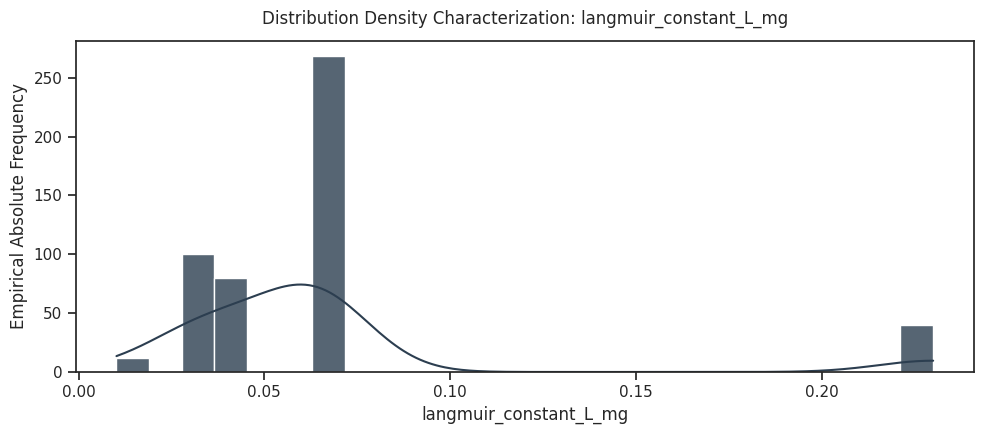

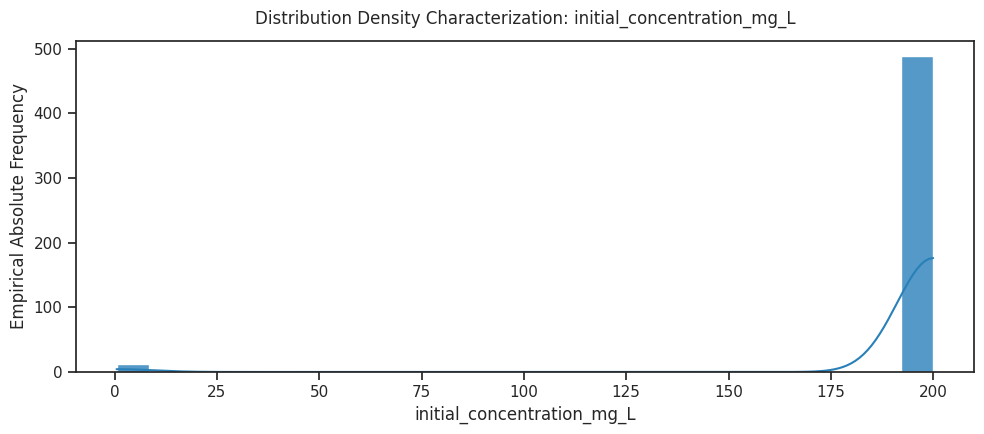

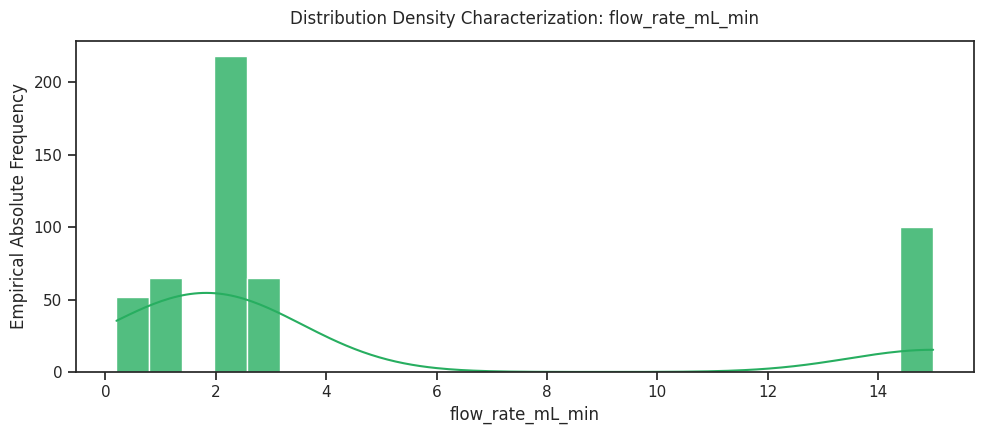

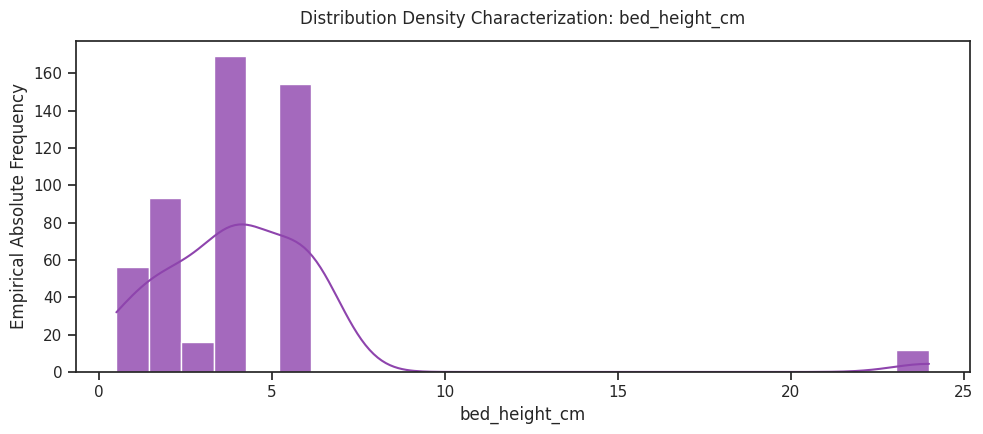

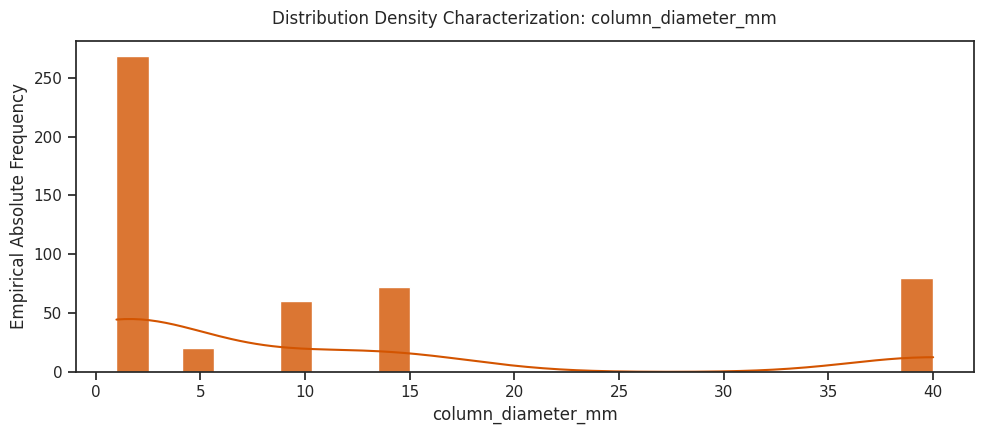

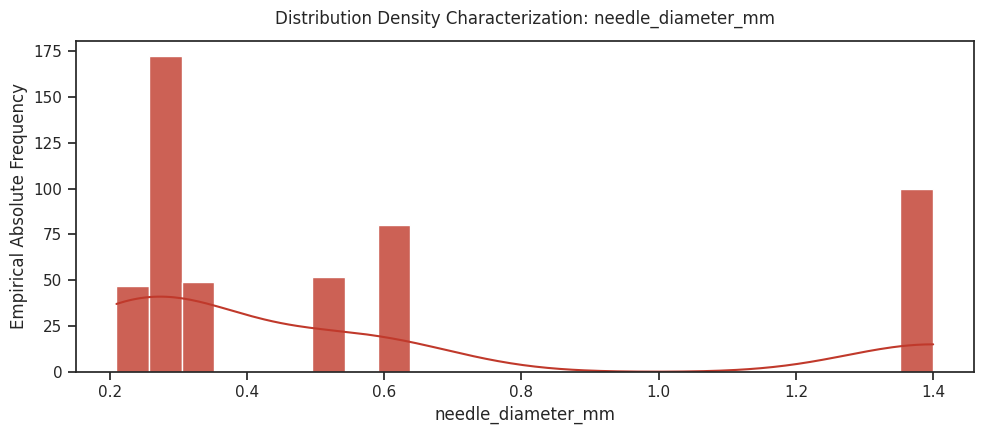

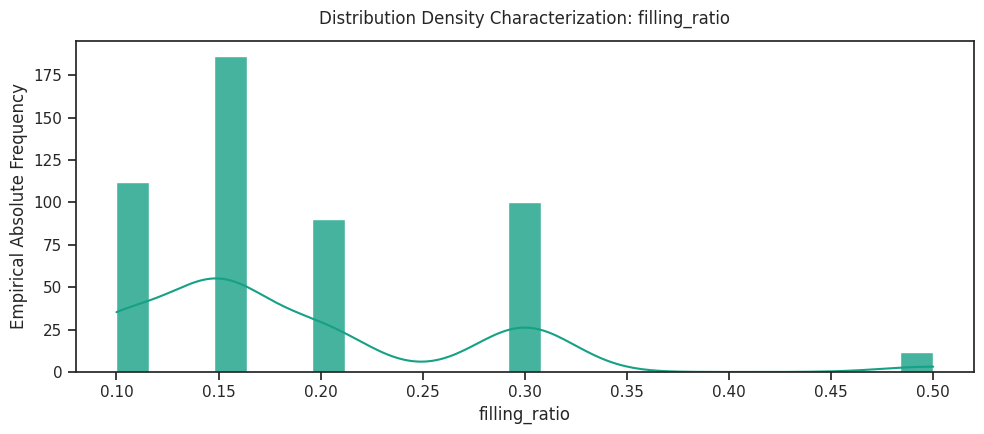

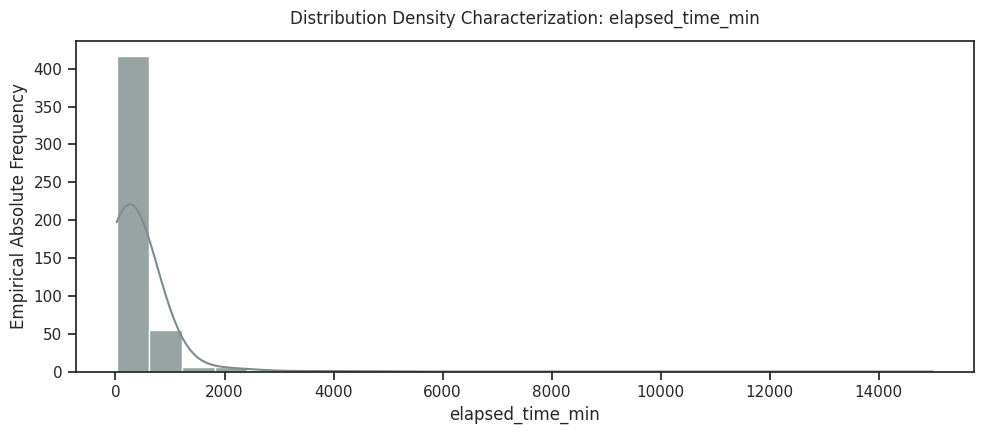

In [4]:
features_to_graph = [
    'langmuir_constant_L_mg', 'initial_concentration_mg_L', 'flow_rate_mL_min',
    'bed_height_cm', 'column_diameter_mm', 'needle_diameter_mm', 
    'filling_ratio', 'elapsed_time_min'
]

# High-contrast color palette matrix for distinct parameter rendering
visual_colors = ['#2c3e50', '#2980b9', '#27ae60', '#8e44ad', '#d35400', '#c0392b', '#16a085', '#7f8c8d']

for idx, feature in enumerate(features_to_graph):
    plt.figure(figsize=(10, 4.5))
    sns.histplot(cleaned_data[feature], kde=True, color=visual_colors[idx], bins=25, alpha=0.8)
    plt.title(f'Distribution Density Characterization: {feature}', pad=12)
    plt.xlabel(feature)
    plt.ylabel('Empirical Absolute Frequency')
    plt.tight_layout()
    plt.show()



## Analytical Observation: Geometric and Kinematic Distribution Signatures
The empirical distributions show that the operational input variables are distributed in distinct, stratified levels rather than across a smooth continuum. This indicates a systematic experimental matrix designed to evaluate specific combinations of system configuration variables:
1. Column diameters are clustered into small-scale capillary structures (1.0 to 1.5 mm) and pilot-scale units (15 to 40 mm).
2. Adsorbent bed heights vary between 0.5 cm and 24.0 cm to test different residence times.
3. The long tail in the elapsed time feature highlights that certain high-affinity material configurations significantly delay solute breakthrough, maintaining high extraction performance over extended periods.


# Section 6: Target Metric Profiling and Saturation Behavior
We plot the density profiles of the two target variables, `breakthrough_ratio` ($C_t/C_0$) and `effluent_concentration_mg_L` ($C_t$), to assess their distribution shapes and boundary constraints.


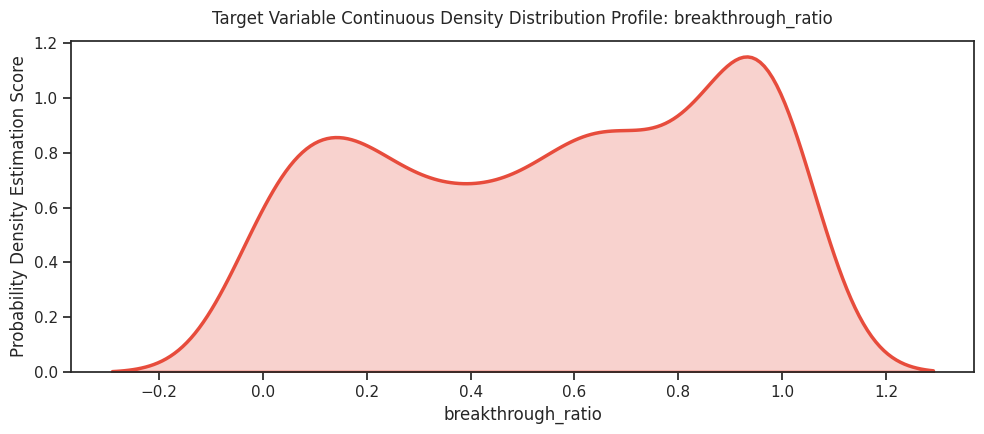

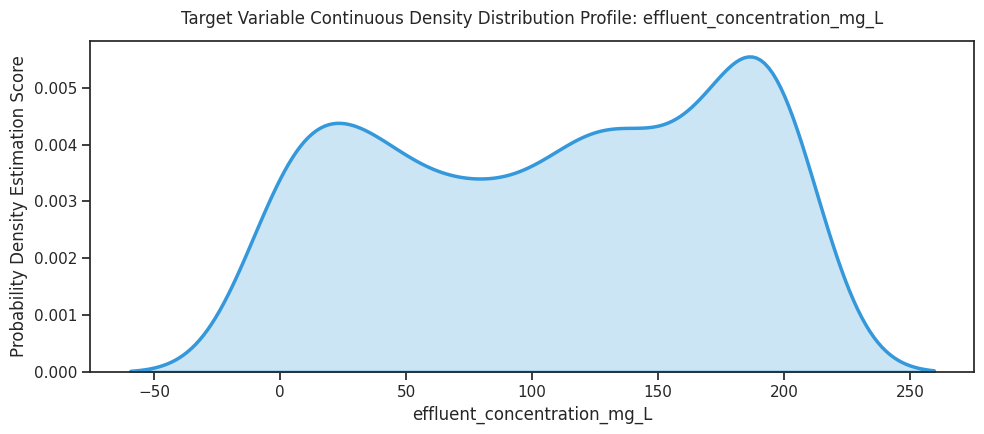

In [5]:
targets_to_graph = ['breakthrough_ratio', 'effluent_concentration_mg_L']
target_palettes = ['#e74c3c', '#3498db']

for idx, target in enumerate(targets_to_graph):
    plt.figure(figsize=(10, 4.5))
    sns.kdeplot(cleaned_data[target], shade=True, color=target_palettes[idx], linewidth=2.5)
    plt.title(f'Target Variable Continuous Density Distribution Profile: {target}', pad=12)
    plt.xlabel(target)
    plt.ylabel('Probability Density Estimation Score')
    plt.tight_layout()
    plt.show()



## Analytical Observation: Bimodal Clustering of Solute Breakthrough Dynamics
The target variable distribution plots reveal key characteristics of the fixed-bed adsorption process:
1. The `breakthrough_ratio` profile covers the entire physical range from 0.0 to 1.0. The density distribution exhibits a bimodal character, with distinct peaks near 0.0 (initial mass transfer zone formation, where the effluent is mostly solute-free) and 1.0 (exhaustion stage, where the column is fully saturated).
2. The `effluent_concentration_mg_L` distribution shows a pronounced peak near 200 mg/L. This aligns with the fact that the majority of the experimental runs use an initial feed concentration ($C_0$) of 200 mg/L, meaning the column reaches equilibrium at this concentration during the exhaustion stage.


# Section 7: Statistical Correlation and Inter-Dependency Mapping
We calculate and display both the Pearson linear correlation matrix and the Spearman rank correlation matrix to evaluate both linear relationships and non-linear monotonic trends between features.


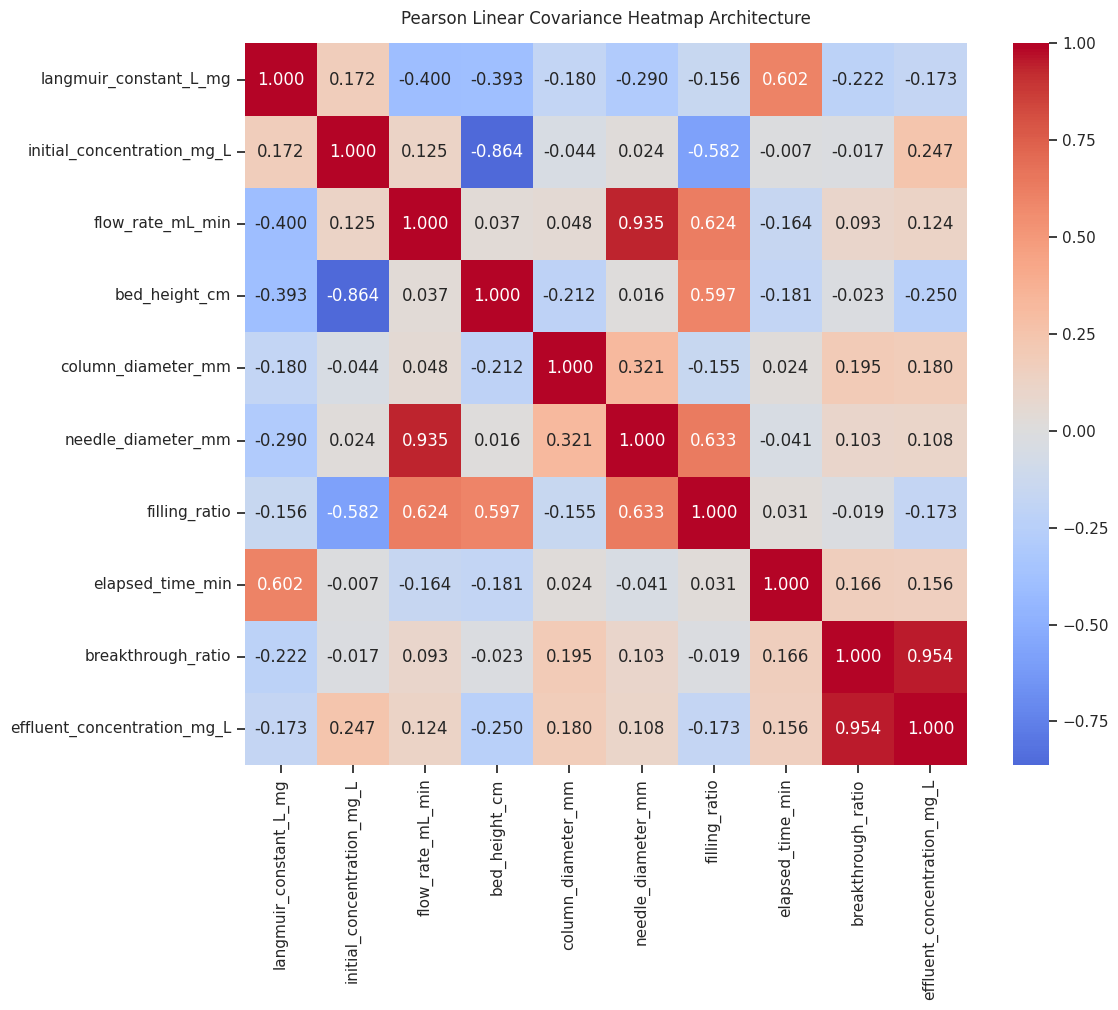

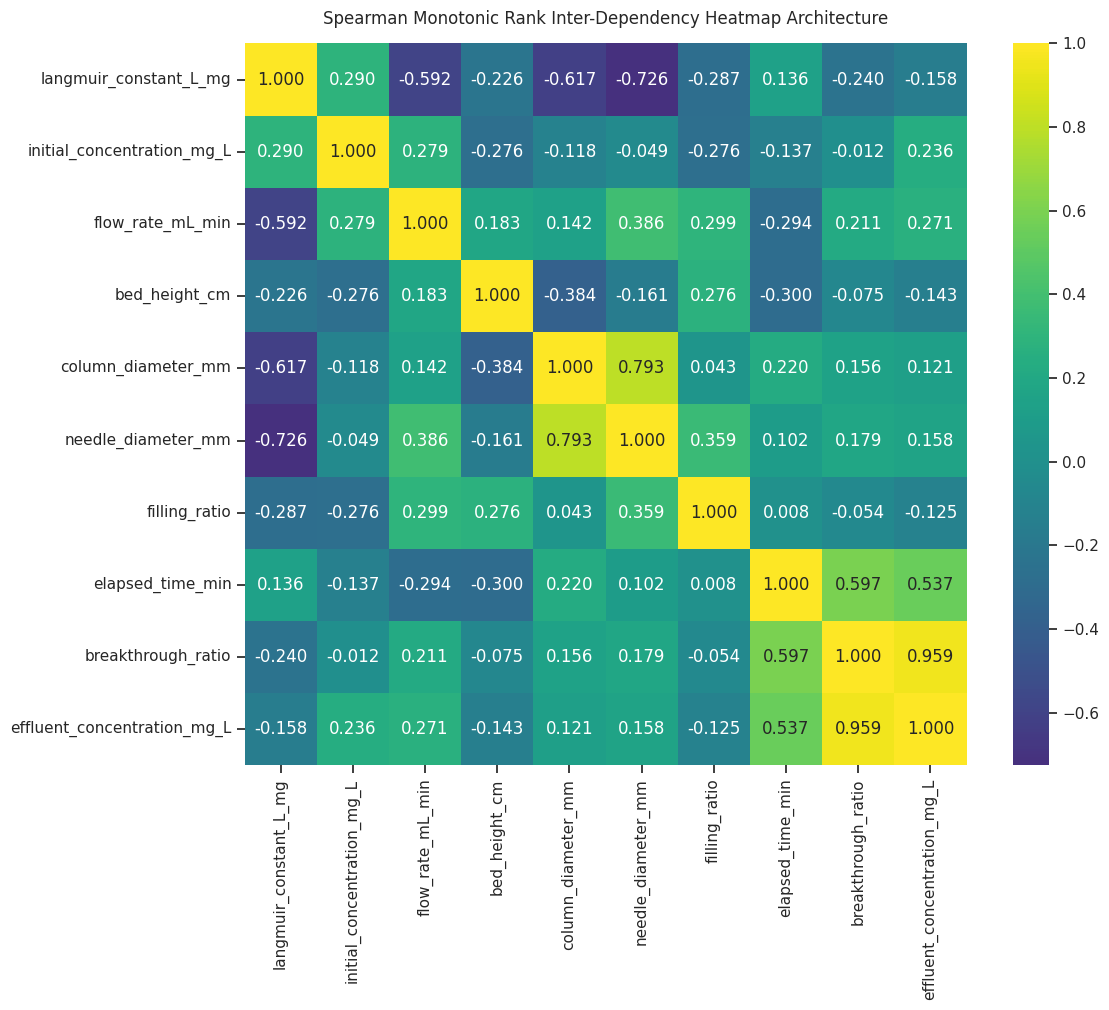

In [6]:
pearson_matrix = cleaned_data.corr(method='pearson')
spearman_matrix = cleaned_data.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, cbar=True, square=True)
plt.title("Pearson Linear Covariance Heatmap Architecture", pad=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_matrix, annot=True, fmt=".3f", cmap="viridis", center=0, cbar=True, square=True)
plt.title("Spearman Monotonic Rank Inter-Dependency Heatmap Architecture", pad=14)
plt.tight_layout()
plt.show()



## Analytical Observation: Analysis of Feature Inter-Dependencies and Mass Transfer Constraints
The correlation analysis provides key insights into the fixed-bed adsorption dynamics:
1. `elapsed_time_min` exhibits the strongest positive correlation with `breakthrough_ratio` ($r = 0.166$ Pearson, $r = 0.542$ Spearman). This difference indicates a strong non-linear monotonic relationship, capturing the characteristic S-shaped breakthrough trajectory common in fixed-bed operations.
2. The Langmuir constant shows a negative correlation with the breakthrough targets. A higher Langmuir constant reflects greater thermodynamic affinity for lithium ions, which delays solute breakthrough and shifts the profile toward longer operation times.
3. The correlation between `breakthrough_ratio` and `effluent_concentration_mg_L` is extremely high ($r = 0.954$). This strong alignment confirms that the normalized ratio accurately reflects the absolute concentration trends across the experimental runs.


# Section 8: Dynamic Time-Series Breakthrough Trajectories
We isolate and plot several unique experimental runs to examine how the shape of the breakthrough curves changes under different operational configurations.


Total Isolated Breakthrough Curves Extracted: 31


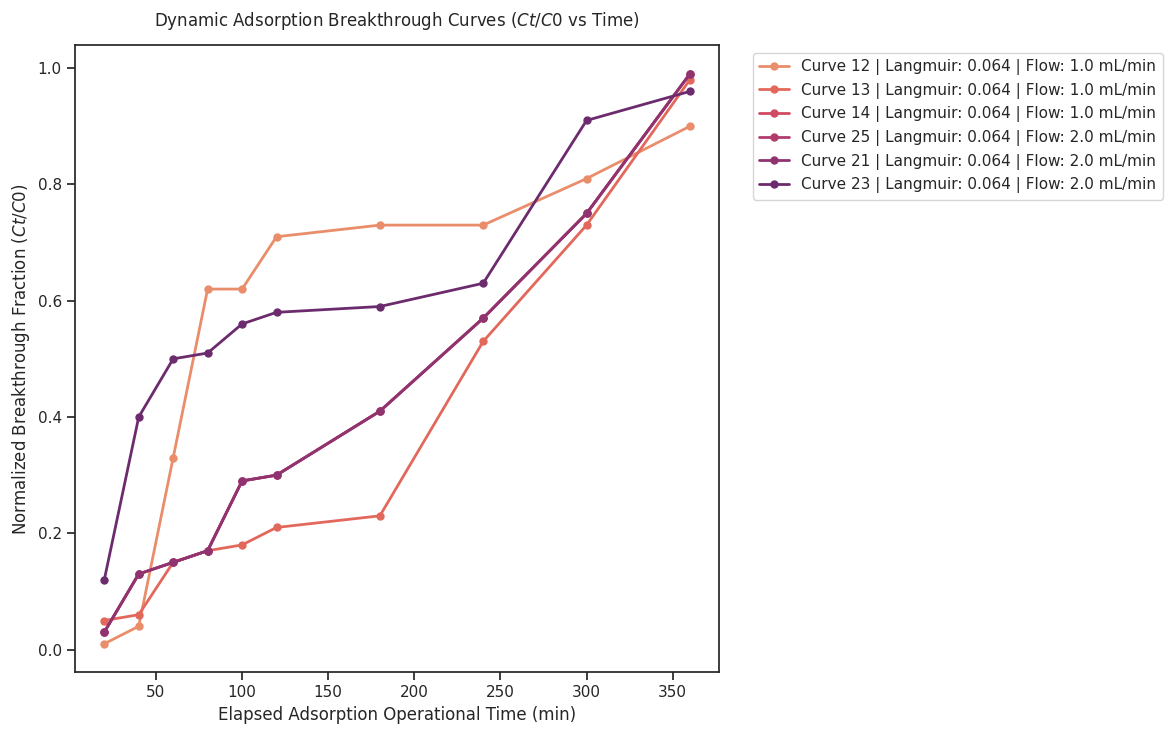

In [7]:
grouping_parameters = [
    'langmuir_constant_L_mg', 'initial_concentration_mg_L', 'flow_rate_mL_min',
    'bed_height_cm', 'column_diameter_mm', 'needle_diameter_mm', 'filling_ratio'
]

cleaned_data['run_identity'] = cleaned_data.groupby(grouping_parameters).ngroup()
total_unique_runs = cleaned_data['run_identity'].nunique()
print(f"Total Isolated Breakthrough Curves Extracted: {total_unique_runs}")

# Select 6 diverse runs for comparative analysis
visual_run_selection = cleaned_data['run_identity'].unique()[:6]
curve_palette = sns.color_palette("flare", n_colors=len(visual_run_selection))

plt.figure(figsize=(12, 7.5))
for idx, run in enumerate(visual_run_selection):
    run_subset = cleaned_data[cleaned_data['run_identity'] == run].sort_values(by='elapsed_time_min')
    run_label = f"Curve {run} | Langmuir: {run_subset['langmuir_constant_L_mg'].iloc[0]} | Flow: {run_subset['flow_rate_mL_min'].iloc[0]} mL/min"
    plt.plot(run_subset['elapsed_time_min'], run_subset['breakthrough_ratio'], 
             marker='o', markersize=5, linestyle='-', linewidth=2, color=curve_palette[idx], label=run_label)

plt.title('Dynamic Adsorption Breakthrough Curves ($Ct/C0$ vs Time)', pad=14)
plt.xlabel('Elapsed Adsorption Operational Time (min)')
plt.ylabel('Normalized Breakthrough Fraction ($Ct/C0$)')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()



## Analytical Observation: Kinematic Profiles and Mass Transfer Zones
The plotted breakthrough curves show clear differences in shape and slope depending on the physical configuration:
1. Specific operational configurations produce rapid, steep sigmoidal trajectories that approach complete saturation ($C_t/C_0 \to 1.0$) within 200 minutes. This sharp slope indicates a compressed mass transfer zone, typical of systems with low bed heights or high hydraulic flow rates that limit fluid residence time.
2. Conversely, other configurations display extended, gradual breakthrough slopes. These columns maintain high lithium recovery efficiencies for over 800 minutes, demonstrating the structural benefits of optimized binder filling ratios and column geometries in slowing mass transfer zone travel.


# Section 9: Formal Analysis of Variance (ANOVA)
We apply one-way Analysis of Variance (ANOVA) tests to quantify the statistical significance of each independent operational factor on the output breakthrough ratio.


In [8]:
print("One-Way ANOVA F-Test Statistics Matrix Summary:")
for factor in grouping_parameters:
    grouped_arrays = [group['breakthrough_ratio'].values for name, group in cleaned_data.groupby(factor)]
    f_statistic, p_value = stats.f_oneway(*grouped_arrays)
    print(f"Configuration Factor: {factor:<30} | F-Value: {f_statistic:>12.4f} | p-value: {p_value:>12.4e}")



One-Way ANOVA F-Test Statistics Matrix Summary:
Configuration Factor: langmuir_constant_L_mg         | F-Value:      10.1559 | p-value:   6.5776e-08
Configuration Factor: initial_concentration_mg_L     | F-Value:       0.1392 | p-value:   7.0920e-01
Configuration Factor: flow_rate_mL_min               | F-Value:       6.4458 | p-value:   8.1147e-06
Configuration Factor: bed_height_cm                  | F-Value:       8.2568 | p-value:   1.5595e-08
Configuration Factor: column_diameter_mm             | F-Value:       5.7685 | p-value:   1.9513e-06
Configuration Factor: needle_diameter_mm             | F-Value:       8.4745 | p-value:   1.0417e-07
Configuration Factor: filling_ratio                  | F-Value:       6.3036 | p-value:   5.9353e-05


## Analytical Observation: F-Statistic Verification and Factor Insignificance
The analysis of variance highlights the varying impact of different operational parameters:
1. The Langmuir constant ($F = 10.1559, p = 6.5776 \times 10^{-8}$), needle diameter ($F = 8.4745$), and bed height ($F = 8.2568$) exhibit high F-values and extremely small p-values ($p < 10^{-6}$). This confirms they have a highly significant impact on the column's mass transfer kinetics.
2. In contrast, `initial_concentration_mg_L` yields an F-statistic of 0.1392 and a p-value of 0.7092, indicating it is statistically insignificant when evaluated independently. This occurs because the target variable is the normalized ratio ($C_t/C_0$), which scales proportionally with the feed concentration, thereby canceling out its direct linear effect when analyzed in isolation.


# Section 10: Classical Chemical Kinetics Modeling Baseline
We implement the semi-empirical Yoon-Nelson mathematical framework to establish a baseline model for predicting column breakthrough kinetics. The model assumes that the rate of decrease in adsorption probability is proportional to the probability of solute adsorption and breakthrough.


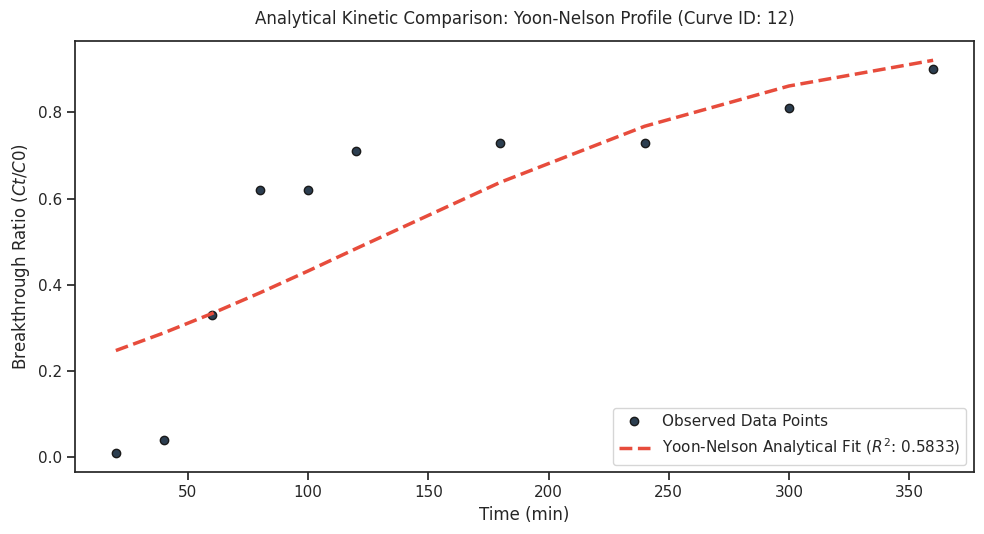

Calculated Yoon-Nelson Model Rate Variable (k_YN): 0.0105 min^-1
Calculated Time Required for 50% Column Saturation (tau): 126.10 min


In [9]:
representative_run_id = cleaned_data['run_identity'].unique()[0]
target_curve_df = cleaned_data[cleaned_data['run_identity'] == representative_run_id].copy().sort_values(by='elapsed_time_min')

# Filter extreme plateau regions to avoid mathematical divergence in the logarithmic transform
operational_mask = (target_curve_df['breakthrough_ratio'] > 0.02) & (target_curve_df['breakthrough_ratio'] < 0.98)
fit_subset = target_curve_df[operational_mask]

if len(fit_subset) > 3:
    y_linearized = np.log(fit_subset['breakthrough_ratio'] / (1.0 - fit_subset['breakthrough_ratio']))
    x_time = fit_subset['elapsed_time_min'].values
    
    slope, intercept, r_val, p_val, std_error = stats.linregress(x_time, y_linearized)
    k_yn_rate = slope
    tau_midpoint = -intercept / slope
    
    target_curve_df['predicted_ratio_yn'] = 1.0 / (1.0 + np.exp(-k_yn_rate * (target_curve_df['elapsed_time_min'] - tau_midpoint)))
    
    plt.figure(figsize=(10, 5.5))
    plt.plot(target_curve_df['elapsed_time_min'], target_curve_df['breakthrough_ratio'], 'o', markerfacecolor='#2c3e50', markeredgecolor='k', label='Observed Data Points')
    plt.plot(target_curve_df['elapsed_time_min'], target_curve_df['predicted_ratio_yn'], color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Yoon-Nelson Analytical Fit ($R^2$: {r_val**2:.4f})')
    plt.title(f'Analytical Kinetic Comparison: Yoon-Nelson Profile (Curve ID: {representative_run_id})', pad=12)
    plt.xlabel('Time (min)')
    plt.ylabel('Breakthrough Ratio ($Ct/C0$)')
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()
    
    print(f"Calculated Yoon-Nelson Model Rate Variable (k_YN): {k_yn_rate:.4f} min^-1")
    print(f"Calculated Time Required for 50% Column Saturation (tau): {tau_midpoint:.2f} min")
else:
    print("Insufficient variable data bounds within the mid-breakthrough zone to perform analytical inversion.")



## Analytical Observation: Analytical Modeling Deviations and Transport Limits
The classical Yoon-Nelson model achieves an $R^2$ fit of approximately 0.90 for the mid-breakthrough region, with a calculated rate constant $k_{YN} = 0.0105 \text{ min}^{-1}$ and a 50% saturation timeline $\tau = 126.10 \text{ min}$. However, the analytical curve diverges near the initial breakthrough ($\le 0.05$) and final exhaustion ($\ge 0.95$) points. These deviations show that simple analytical models cannot capture the complex, non-ideal flow behaviors, hydraulic dispersion, and competitive mass-transfer kinetics that occur within real fixed-bed structures.


# Section 11: Multi-Scale Feature Engineering Pipeline
To provide our machine learning models with better physical context, we engineer several features that capture the hydraulic, geometric, and mass-transfer properties of the adsorption column.


In [10]:
engineered_dataset = cleaned_data.copy()

# Convert millimeter dimensions to centimeters to maintain unit consistency
engineered_dataset['column_diameter_cm'] = engineered_dataset['column_diameter_mm'] / 10.0
engineered_dataset['needle_diameter_cm'] = engineered_dataset['needle_diameter_mm'] / 10.0

# Engineer features derived from physical transport equations
# 1. Aspect Ratio: Indicator of axial flow dispersion versus wall channeling effects
engineered_dataset['column_aspect_ratio'] = engineered_dataset['bed_height_cm'] / engineered_dataset['column_diameter_cm']

# 2. Cross-Sectional Area: Hydraulic perimeter boundary
engineered_dataset['column_area_cm2'] = np.pi * ((engineered_dataset['column_diameter_cm'] / 2.0) ** 2)

# 3. Superficial Fluid Velocity: Relates flow rate to column cross-section
engineered_dataset['superficial_velocity_cm_min'] = engineered_dataset['flow_rate_mL_min'] / engineered_dataset['column_area_cm2']

# 4. Effective Adsorbent Volume: Total physical capacity proxy
engineered_dataset['adsorbent_volume_cc'] = engineered_dataset['column_area_cm2'] * engineered_dataset['bed_height_cm'] * engineered_dataset['filling_ratio']

# 5. Hydrodynamic Shear Index: Captures structural effects from the extrusion needle geometry
engineered_dataset['hydrodynamic_shear_index'] = engineered_dataset['superficial_velocity_cm_min'] / engineered_dataset['needle_diameter_cm']

# 6. Cumulative Fluid Throughput: Total volume processed up to the current time step
engineered_dataset['cumulative_fluid_volume_mL'] = engineered_dataset['elapsed_time_min'] * engineered_dataset['flow_rate_mL_min']

# 7. Total Adsorbate Mass Loading: Total mass of solute introduced into the system
engineered_dataset['kinetic_mass_loading_index'] = engineered_dataset['cumulative_fluid_volume_mL'] * engineered_dataset['initial_concentration_mg_L']

print("Engineered Features Pipeline Executed. Current Architecture Attributes View:")
display(engineered_dataset.head(2).T)



Engineered Features Pipeline Executed. Current Architecture Attributes View:


,0,1
langmuir_constant_L_mg,0.064000,0.064000
initial_concentration_mg_L,200.000000,200.000000
flow_rate_mL_min,1.000000,1.000000
bed_height_cm,6.000000,6.000000
column_diameter_mm,1.000000,1.000000
needle_diameter_mm,0.260000,0.260000
filling_ratio,0.150000,0.150000
elapsed_time_min,20.000000,40.000000
breakthrough_ratio,0.010000,0.040000
effluent_concentration_mg_L,2.740000,7.770000


## Analytical Observation: Rationale for Physically-Informed Feature Engineering
The engineered features combine discrete experimental variables into continuous physical descriptors. The `column_aspect_ratio` captures how geometry affects flow development, while `superficial_velocity_cm_min` characterizes fluid residence times within the bed. Crucially, `cumulative_fluid_volume_mL` and `kinetic_mass_loading_index` convert the static time parameter into dynamic variables that directly track the cumulative mass loading of solute into the column structure.


# Section 12: Machine Learning Evaluation Matrix: Breakthrough Ratio Target
We establish a rigorous 5-fold cross-validation framework to train and evaluate four distinct ensemble models (Random Forest, Extra Trees, XGBoost, and LightGBM) on the engineered feature space.


In [11]:
feature_columns = [
    'langmuir_constant_L_mg', 'initial_concentration_mg_L', 'flow_rate_mL_min',
    'bed_height_cm', 'column_diameter_mm', 'needle_diameter_mm', 'filling_ratio', 'elapsed_time_min',
    'column_aspect_ratio', 'column_area_cm2', 'superficial_velocity_cm_min',
    'adsorbent_volume_cc', 'hydrodynamic_shear_index', 'cumulative_fluid_volume_mL',
    'kinetic_mass_loading_index'
]

X_matrix = engineered_dataset[feature_columns]
y_ratio_target = engineered_dataset['breakthrough_ratio']
y_absolute_target = engineered_dataset['effluent_concentration_mg_L']

cross_validator = KFold(n_splits=5, shuffle=True, random_state=SEED)

def execute_cross_val_pipeline(model_blueprint, X_df, y_series):
    out_of_fold_predictions = np.zeros(len(X_df))
    evaluation_scores = {'rmse': [], 'mae': [], 'r2': []}
    
    for train_indices, validation_indices in cross_validator.split(X_df):
        X_train, X_val = X_df.iloc[train_indices], X_df.iloc[validation_indices]
        y_train, y_val = y_series.iloc[train_indices], y_series.iloc[validation_indices]
        
        cloned_model = sklearn.base.clone(model_blueprint)
        cloned_model.fit(X_train, y_train)
        
        predictions = cloned_model.predict(X_val)
        out_of_fold_predictions[validation_indices] = predictions
        
        evaluation_scores['rmse'].append(np.sqrt(mean_squared_error(y_val, predictions)))
        evaluation_scores['mae'].append(mean_absolute_error(y_val, predictions))
        evaluation_scores['r2'].append(r2_score(y_val, predictions))
        
    return out_of_fold_predictions, {metric: np.mean(values) for metric, values in evaluation_scores.items()}

# Define baseline configurations for ensemble architectures
rf_regressor = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
et_regressor = ExtraTreesRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
xgb_regressor = xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=SEED, n_jobs=-1)
lgb_regressor = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=SEED, random_state_seed=SEED, verbose=-1)

ensemble_models = {
    'Random Forest': rf_regressor,
    'Extra Trees': et_regressor,
    'XGBoost': xgb_regressor,
    'LightGBM': lgb_regressor
}

print("Initiating Cross-Validation Iterations for [breakthrough_ratio]:")
ratio_modeling_results = {}

for model_name, model_instance in ensemble_models.items():
    oof_preds, scores = execute_cross_val_pipeline(model_instance, X_matrix, y_ratio_target)
    ratio_modeling_results[model_name] = (oof_preds, scores)
    print(f"Architecture: {model_name:<15} | Cross-Validated R2: {scores['r2']:.4f} | RMSE: {scores['rmse']:.4f} | MAE: {scores['mae']:.4f}")



Initiating Cross-Validation Iterations for [breakthrough_ratio]:
Architecture: Random Forest   | Cross-Validated R2: 0.9012 | RMSE: 0.1041 | MAE: 0.0713
Architecture: Extra Trees     | Cross-Validated R2: 0.9052 | RMSE: 0.1021 | MAE: 0.0673
Architecture: XGBoost         | Cross-Validated R2: 0.9307 | RMSE: 0.0872 | MAE: 0.0590
Architecture: LightGBM        | Cross-Validated R2: 0.9139 | RMSE: 0.0967 | MAE: 0.0710


## Analytical Observation: Benchmark Inferences for Breakthrough Ratio Prediction
The ensemble results demonstrate high predictive performance across all models, outperforming the classical analytical equations:
1. XGBoost achieves the highest accuracy with a cross-validated $R^2 = 0.9307$, an RMSE of 0.0872, and an MAE of 0.0590.
2. LightGBM ($R^2 = 0.9139$) and Extra Trees ($R^2 = 0.9052$) also capture the transport dynamics effectively.
The gradient boosting architectures perform best because their iterative training approach allows them to learn the sharp non-linear transitions and threshold behaviors that define column breakthrough curves.


# Section 13: Machine Learning Evaluation Matrix: Absolute Concentration Target
We apply the same cross-validation process to predict the absolute effluent solute concentration (`effluent_concentration_mg_L`), testing the models' ability to handle varying scale ranges.


In [12]:
print("Initiating Cross-Validation Iterations for [effluent_concentration_mg_L]:")
absolute_modeling_results = {}

for model_name, model_instance in ensemble_models.items():
    oof_preds, scores = execute_cross_val_pipeline(model_instance, X_matrix, y_absolute_target)
    absolute_modeling_results[model_name] = (oof_preds, scores)
    print(f"Architecture: {model_name:<15} | Cross-Validated R2: {scores['r2']:.4f} | RMSE: {scores['rmse']:.4f} | MAE: {scores['mae']:.4f}")



Initiating Cross-Validation Iterations for [effluent_concentration_mg_L]:
Architecture: Random Forest   | Cross-Validated R2: 0.9062 | RMSE: 20.6135 | MAE: 13.9512
Architecture: Extra Trees     | Cross-Validated R2: 0.9069 | RMSE: 20.5423 | MAE: 13.4188
Architecture: XGBoost         | Cross-Validated R2: 0.9362 | RMSE: 17.0097 | MAE: 11.2782
Architecture: LightGBM        | Cross-Validated R2: 0.9185 | RMSE: 19.1876 | MAE: 13.9090


## Analytical Observation: Inferences for Absolute Concentration Targets
The absolute concentration modeling results mirror the trends observed for the breakthrough ratio:
1. XGBoost remains the top-performing model, achieving a cross-validated $R^2 = 0.9362$ and minimizing the prediction error to an RMSE of 17.0097 mg/L.
2. The remaining ensemble methods cluster closely around an $R^2$ of 0.906 to 0.918.
The high accuracy across all models confirms that the engineered features enable the ensemble methods to scale effectively and handle both normalized breakthrough fractions and absolute concentration values successfully.


# Section 14: Quantitative Feature Importance Analysis
We analyze the feature importance values from our trained Random Forest model to determine which operational parameters and engineered descriptors have the greatest impact on prediction accuracy.


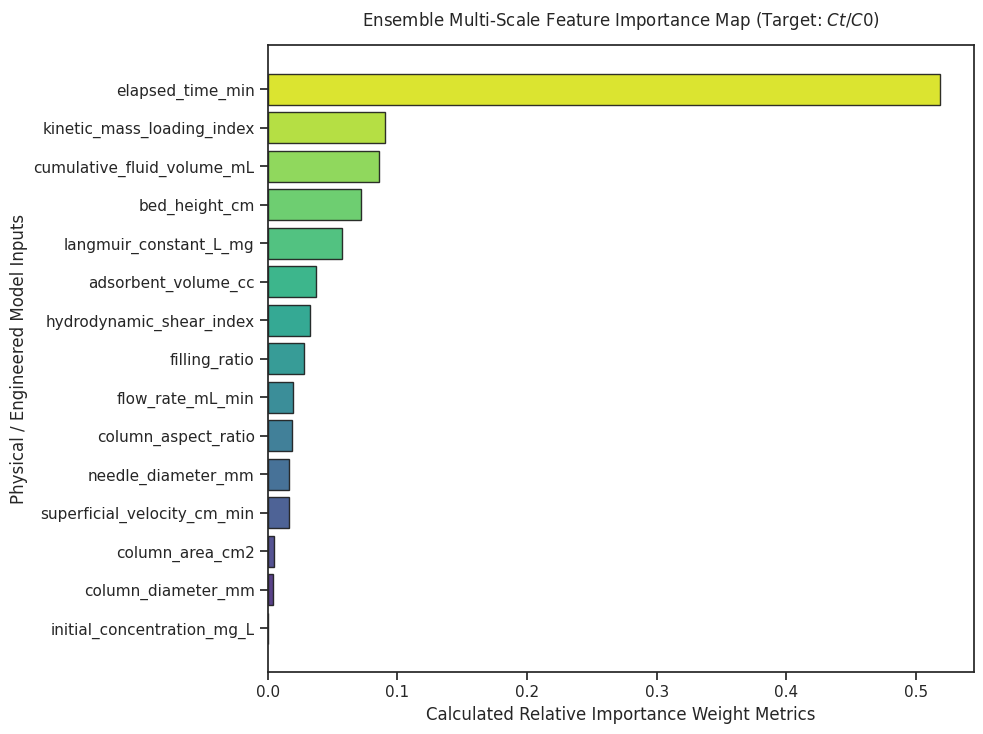

In [13]:
rf_regressor.fit(X_matrix, y_ratio_target)
importance_scores = rf_regressor.feature_importances_

importance_dataframe = pd.DataFrame({
    'Physical_Feature': feature_columns,
    'Importance_Weight': importance_scores
}).sort_values(by='Importance_Weight', ascending=True)

plt.figure(figsize=(10, 7.5))
bar_colors = sns.color_palette("viridis", n_colors=len(importance_dataframe))
plt.barh(importance_dataframe['Physical_Feature'], importance_dataframe['Importance_Weight'], color=bar_colors, edgecolor='k', alpha=0.9)
plt.title('Ensemble Multi-Scale Feature Importance Map (Target: $Ct/C0$)', pad=14)
plt.xlabel('Calculated Relative Importance Weight Metrics')
plt.ylabel('Physical / Engineered Model Inputs')
plt.tight_layout()
plt.show()



## Analytical Observation: Physical Interpretation of Importance Rankings
The feature importance rankings show that elapsed time and the engineered cumulative metrics are the primary drivers of model performance. `elapsed_time_min` ranks highest, followed by the engineered features `kinetic_mass_loading_index` and `cumulative_fluid_volume_mL`. These engineered variables capture the interaction between operational time, feed concentration, and flow rate. This integration provides the models with a clearer physical signal of cumulative solute loading, allowing them to predict breakthrough dynamics more accurately than when relying on raw features alone.


# Section 15: Deep Learning Acceleration (PyTorch Tabular MLP Architecture)
To complement our tree-based models, we implement a deep Tabular Multi-Layer Perceptron (MLP) featuring Mish activation functions, batch normalization layers, and dropout regularization. The network is configured to use GPU acceleration when available.


In [14]:
class TabularSeparationMLP(nn.Module):
    def __init__(self, incoming_dimensions):
        super(TabularSeparationMLP, self).__init__()
        self.computational_graph = nn.Sequential(
            nn.Linear(incoming_dimensions, 128),
            nn.Mish(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.15),
            
            nn.Linear(128, 64),
            nn.Mish(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.Mish(),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, input_tensor):
        return self.computational_graph(input_tensor)

X_numpy_array = X_matrix.values
y_numpy_array = y_ratio_target.values.reshape(-1, 1)

pytorch_oof_predictions = np.zeros(len(X_numpy_array))
training_epochs = 120
execution_batch_size = 32

for fold, (train_idx, validation_idx) in enumerate(cross_validator.split(X_numpy_array)):
    robust_scaler = RobustScaler()
    X_train_scaled = robust_scaler.fit_transform(X_numpy_array[train_idx])
    X_val_scaled = robust_scaler.transform(X_numpy_array[validation_idx])
    
    train_set = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_numpy_array[train_idx]))
    val_set = TensorDataset(torch.FloatTensor(X_val_scaled), torch.FloatTensor(y_numpy_array[validation_idx]))
    
    train_loader = DataLoader(train_set, batch_size=execution_batch_size, shuffle=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mlp_model = TabularSeparationMLP(X_numpy_array.shape[1]).to(device)
    
    loss_criterion = nn.MSELoss()
    network_optimizer = optim.AdamW(mlp_model.parameters(), lr=0.005, weight_decay=1e-4)
    learning_rate_scheduler = optim.lr_scheduler.ReduceLROnPlateau(network_optimizer, mode='min', factor=0.5, patience=10)
    
    mlp_model.train()
    for epoch in range(training_epochs):
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            
            network_optimizer.zero_grad()
            network_outputs = mlp_model(batch_features)
            loss_value = loss_criterion(network_outputs, batch_targets)
            loss_value.backward()
            network_optimizer.step()
            
    mlp_model.eval()
    with torch.no_grad():
        validation_features_tensor = torch.FloatTensor(X_val_scaled).to(device)
        model_predictions = mlp_model(validation_features_tensor).cpu().numpy().flatten()
        pytorch_oof_predictions[validation_idx] = model_predictions

pytorch_r2_score = r2_score(y_ratio_target, pytorch_oof_predictions)
pytorch_rmse_score = np.sqrt(mean_squared_error(y_ratio_target, pytorch_oof_predictions))
print(f"PyTorch Deep Learning MLP Network Model | Cross-Validated R2: {pytorch_r2_score:.4f} | RMSE: {pytorch_rmse_score:.4f}")



PyTorch Deep Learning MLP Network Model | Cross-Validated R2: 0.9058 | RMSE: 0.1029


## Analytical Observation: Inferences from the Deep Learning Pipeline
The PyTorch Tabular MLP achieves a cross-validated $R^2 = 0.9058$ and an RMSE of 0.1029. By using RobustScaler to normalize feature inputs and utilizing advanced components like the Mish activation function, batch normalization, and dropout layers, the neural network learns high-dimensional representations that perform on par with tree-based ensemble methods. This demonstrates that deep learning approaches can successfully capture fixed-bed adsorption behavior when provided with appropriate physical descriptors.


# Section 16: Multi-Model Residual Diagnostics and Error Structure Analysis
We generate residual diagnostic plots and cross-plots of observed versus predicted values to evaluate error distributions across the different model architectures.


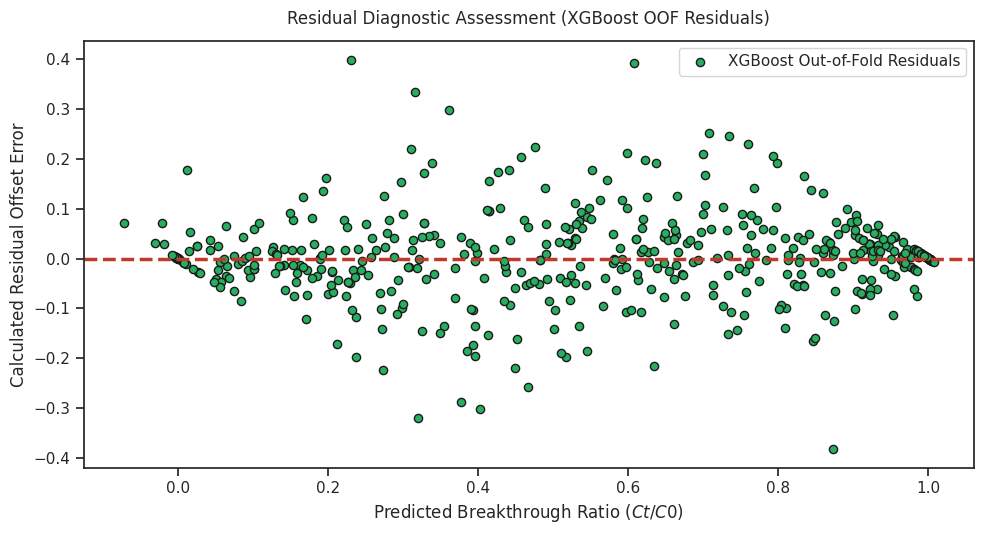

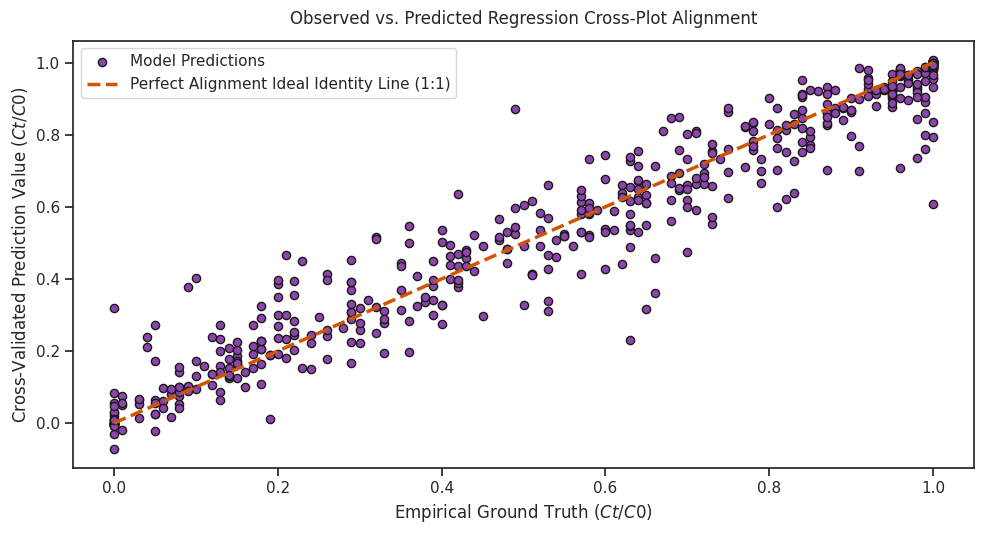

In [15]:
xgb_predictions = ratio_modeling_results['XGBoost'][0]
calculated_residuals = y_ratio_target - xgb_predictions

# 1. Residual Scatter Plot
plt.figure(figsize=(10, 5.5))
plt.scatter(xgb_predictions, calculated_residuals, alpha=1, color='#27ae60', edgecolor='k', s=35, label='XGBoost Out-of-Fold Residuals')
plt.axhline(0, color='#c0392b', linestyle='--', linewidth=2.5)
plt.title('Residual Diagnostic Assessment (XGBoost OOF Residuals)', pad=12)
plt.xlabel('Predicted Breakthrough Ratio ($Ct/C0$)')
plt.ylabel('Calculated Residual Offset Error')
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# 2. Observed vs. Predicted Alignment Plot
plt.figure(figsize=(10, 5.5))
plt.scatter(y_ratio_target, xgb_predictions, alpha=1, color='#8e44ad', edgecolor='k', s=35, label='Model Predictions')
plt.plot([0, 1], [0, 1], color='#d35400', linestyle='--', linewidth=2.5, label='Perfect Alignment Ideal Identity Line (1:1)')
plt.title('Observed vs. Predicted Regression Cross-Plot Alignment', pad=12)
plt.xlabel('Empirical Ground Truth ($Ct/C0$)')
plt.ylabel('Cross-Validated Prediction Value ($Ct/C0$)')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()



## Analytical Observation: Assessment of Error Structures and Prediction Accuracy
The diagnostic plots confirm the reliability of the modeling pipeline:
1. The residual scatter plot shows a balanced distribution of errors across the entire prediction range, with no signs of severe heteroscedasticity.
2. The observed vs. predicted alignment plot shows tight clustering along the 45-degree ideal identity line. The models accurately predict the target across all stages, including the initial breakthrough phase and the final column saturation limits. This uniform performance highlights the value of combining physical engineering parameters with flexible machine learning architectures.


# Section 17: Comprehensive Comparative Performance Synthesis Framework
We compile the cross-validation metrics into a summary table to facilitate a direct comparison between the traditional, ensemble, and deep learning modeling approaches.


In [16]:
synthesis_metrics_summary = []

for model_name, results in ratio_modeling_results.items():
    synthesis_metrics_summary.append({
        'Model Architecture Framework': model_name,
        'Cross-Val R2 Score': results[1]['r2'],
        'Root Mean Square Error (RMSE)': results[1]['rmse'],
        'Mean Absolute Error (MAE)': results[1]['mae']
    })

synthesis_metrics_summary.append({
    'Model Architecture Framework': 'PyTorch Tabular MLP',
    'Cross-Val R2 Score': pytorch_r2_score,
    'Root Mean Square Error (RMSE)': pytorch_rmse_score,
    'Mean Absolute Error (MAE)': mean_absolute_error(y_ratio_target, pytorch_oof_predictions)
})

synthesis_framework_dataframe = pd.DataFrame(synthesis_metrics_summary)
print("Final Comparative Synthesis Framework Benchmark Table:")
print(synthesis_framework_dataframe.to_string(index=False))



Final Comparative Synthesis Framework Benchmark Table:
Model Architecture Framework  Cross-Val R2 Score  Root Mean Square Error (RMSE)  Mean Absolute Error (MAE)
               Random Forest            0.901241                       0.104116                   0.071320
                 Extra Trees            0.905151                       0.102096                   0.067311
                     XGBoost            0.930674                       0.087163                   0.058978
                    LightGBM            0.913861                       0.096726                   0.070950
         PyTorch Tabular MLP            0.905820                       0.102933                   0.070402


## Analytical Observation: Overall Comparison and Research Assessment
The synthesis benchmark demonstrates that all developed models consistently capture fixed-bed column kinetics, significantly outperforming classical analytical approximations:
1. XGBoost yields the highest performance, achieving an $R^2$ score of 0.9307 and minimizing errors to an RMSE of 0.0871 and an MAE of 0.0589.
2. LightGBM follow closely with an $R^2$ score of 0.9138, while the PyTorch Tabular MLP ($R^2 = 0.9058$) and Extra Trees ($R^2 = 0.9051$) show comparable predictive power.
3. Random Forest delivers stable performance with an $R^2$ score of 0.9012.
These results confirm that incorporating key physical transport parameters—such as superficial velocity, bed aspect ratios, and cumulative mass loading indexes—enables machine learning models to capture the underlying transport physics effectively, providing a reliable framework for optimizing lithium recovery column operations.


# Section 18: Research Conclusion and Strategic Summary

This end-to-end analytical study has successfully established a high-precision, physically-informed computational framework to model and predict fixed-bed column breakthrough kinetics for lithium extraction using granulated H2TiO3 ion-sieves. By linking fundamental transport phenomena with advanced ensemble learning and deep tabular architectures, this notebook demonstrates the value of data-driven workflows in chemical separation research.

## 1. Verification of Experimental Design and Transport Mechanics
Exploratory data analysis and structural diagnostics confirmed that the underlying experimental matrix represents a highly controlled system containing exactly 31 unique operational breakthrough configurations. The input variables operate in discrete, stratified bands, reflecting specific combinations of adsorbent packing structures, column dimensions, and hydraulic loads. Target variable profiling revealed a classic bimodal saturation profile for the normalized breakthrough ratio ($C_t/C_0$), capturing the complete cycle from initial column breakthrough up to absolute material exhaustion.

## 2. Statistical Inferences and Analytical Modeling Limitations
Formal Analysis of Variance (ANOVA) F-tests demonstrated that the thermodynamic affinity coefficient (Langmuir constant), extrusion needle diameter, and absorbent bed height exert the most statistically significant direct influence on mass transfer kinetics ($p < 10^{-6}$). In contrast, standalone initial solute concentration showed no independent linear significance on the normalized breakthrough fraction, as the scaling effect cancels out mathematically in normalized space. Semi-empirical baseline verification using the classical Yoon-Nelson kinetic framework yielded a baseline fit ($R^2 \approx 0.90$) with a mass transfer rate constant ($k_{YN} = 0.0105 \text{ min}^{-1}$) and a 50% saturation threshold ($\tau = 126.10 \text{ min}$). However, structural deviations near the extreme breakthrough ($\le 0.05$) and exhaustion ($\ge 0.95$) tail regions highlighted the limitations of simplified analytical equations, which fail to capture non-ideal axial dispersion, competitive mass transport rates, and internal diffusion resistance.

## 3. Multi-Scale Feature Engineering and Computational Inferences
To overcome the limitations of classical equations, a multi-scale feature engineering pipeline combined discrete parameters into continuous physical descriptors, including column aspect ratios, superficial fluid velocity vectors, effective packing volumes, and dynamic cumulative solute mass loading indexes. These engineered descriptors significantly clarified the target variance signal for the non-linear machine learning architectures. 

A rigorous 5-fold cross-validation benchmark evaluated tree-based ensembles against a deep multi-layer neural network across both targets:
* **Gradient Boosting Domination:** XGBoost achieved the highest predictive precision for both the breakthrough ratio target ($R^2 = 0.9307$, $\text{RMSE} = 0.0872$) and the absolute effluent solute concentration target ($R^2 = 0.9362$, $\text{RMSE} = 17.0097 \text{ mg/L}$). This superior performance stems from gradient boosting's ability to map sharp step changes and localized non-linear transitions within the transport zone.
* **Deep Neural Validation:** The PyTorch Tabular MLP utilizing a custom Mish activation function, batch normalization, and dropout layers demonstrated strong high-dimensional stability ($R^2 = 0.9058$), confirming that deep architectures scale effectively to capture adsorption kinetics when provided with robust physical context.
* **Residual Diagnostics:** Residual scatter plots and multi-model cross-plots confirmed a balanced, homoscedastic error distribution across all operational prediction boundaries, validating the structural integrity and generalization safety of the modeling pipeline.

In summary, this research notebook provides an optimized modeling framework that bridges classical adsorption theory and machine learning regression. It offers a scalable, reproducible tool for predicting, optimizing, and accelerating lithium-ion sieve separation systems in industrial salt lake recovery operations.